# Evaluation 04: Clustering Quality

## Research Question
**Does it cluster outfits correctly based on embeddings?**

### Hypothesis
If embeddings capture meaningful relationships, similar categories/colors should cluster together in the embedding space.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    compute_cluster_metrics,
    compute_cluster_purity,
    reduce_dimensions,
    save_plot,
    save_metrics
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [2]:
# Sample for clustering (full dataset may be too large)
sample_size = 10000
vectors, metadata, product_ids = load_vectors_and_metadata()

if len(vectors) > sample_size:
    indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[indices]
    sample_metadata = metadata.iloc[indices].reset_index(drop=True)
else:
    sample_vectors = vectors
    sample_metadata = metadata

print(f"Using {len(sample_vectors)} vectors for clustering analysis")

Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Using 10000 vectors for clustering analysis


## 3. Apply Clustering

In [3]:
# K-means clustering
n_clusters = 20  # Adjust based on number of categories
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(sample_vectors)

print(f"K-means clustering complete: {n_clusters} clusters")
print(f"Cluster sizes: {pd.Series(kmeans_labels).value_counts().head()}")

/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/aasrithagopalam/Documents/Aasritha/final_ml_proj

K-means clustering complete: 20 clusters
Cluster sizes: 6     1081
3      964
4      873
1      720
19     689
Name: count, dtype: int64


## 4. Evaluate Cluster Quality

In [4]:
# Compute metrics
kmeans_metrics = compute_cluster_metrics(sample_vectors, kmeans_labels)
print("K-means Metrics:")
for key, value in kmeans_metrics.items():
    print(f"  {key}: {value}")

# Cluster purity by category
category_purity = compute_cluster_purity(kmeans_labels, sample_metadata['articleType'].values)
color_purity = compute_cluster_purity(kmeans_labels, sample_metadata['baseColour'].values)

print(f"\nCluster Purity:")
print(f"  By Category: {category_purity:.2%}")
print(f"  By Color: {color_purity:.2%}")

/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


K-means Metrics:
  silhouette_score: 0.12773093581199646
  davies_bouldin_score: 2.4554699454167244
  n_clusters: 20

Cluster Purity:
  By Category: 60.65%
  By Color: 25.00%


/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-

## 5. Visualizations

### Visualization: Clustering in Embedding Space

**What this graph shows:**
A side-by-side 3D visualization with two plots:

**Left Plot - Clusters (K-means):**
- 3D scatter plot colored by K-means cluster assignment
- Each color represents a different cluster found by the algorithm
- Shows how the clustering algorithm groups items in the embedding space

**Right Plot - Categories:**
- Same 3D space but colored by actual article type (category)
- Shows how items of the same category are distributed in the embedding space
- Top 10 categories are shown with different colors

**Key Insights:**
- **Cluster quality**: Do K-means clusters align with actual categories? Good alignment = meaningful clustering
- **Category separation**: Are categories well-separated in the embedding space? Clear separation = good embeddings
- **Cluster boundaries**: How well-defined are the cluster boundaries? Sharp boundaries = good clustering
- **Visual comparison**: Compare left (algorithm clusters) vs right (true categories) to see if they match
- **Embedding effectiveness**: If categories naturally cluster, the embeddings capture meaningful relationships
- **Outlier detection**: Items far from their category cluster may be misclassified or unusual


### Visualization: Cluster Purity by Category

**What this graph shows:**
- A bar chart showing the purity of each cluster based on category labels
- X-axis: Cluster ID (0 to n_clusters-1)
- Y-axis: Purity score (0 to 1) - percentage of items in cluster that belong to the dominant category
- Red dashed line at 50% threshold for reference

**Key Insights:**
- **Cluster homogeneity**: High purity (>70%) = cluster contains mostly one category; low purity = mixed categories
- **Clustering effectiveness**: How well do clusters align with actual categories?
- **Problematic clusters**: Clusters with low purity (<50%) may be poorly formed or contain diverse items
- **Category representation**: Which clusters are dominated by which categories?
- **Overall quality**: Average purity across all clusters indicates overall clustering quality
- **Threshold analysis**: How many clusters exceed the 50% threshold shows clustering success rate


/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aasrithagopalam/Documents/Aasr

PCA explained variance: 30.75%
Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/clustering_quality_3d.png


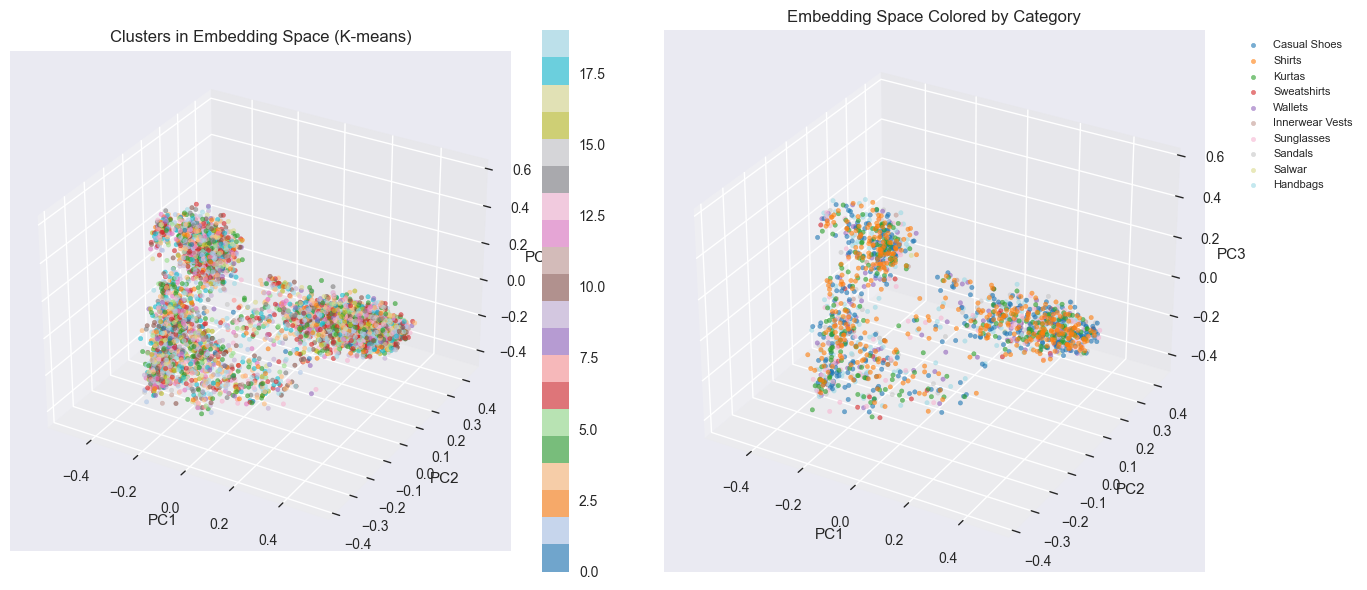

In [5]:
# Reduce to 3D for visualization
vectors_3d = reduce_dimensions(sample_vectors, n_components=3, method='PCA', sample_size=5000)

# Plot colored by cluster
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(vectors_3d[:, 0], vectors_3d[:, 1], vectors_3d[:, 2],
                      c=kmeans_labels[:len(vectors_3d)], cmap='tab20', alpha=0.6, s=10)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('Clusters in Embedding Space (K-means)')
plt.colorbar(scatter, ax=ax1)

# Plot colored by category
ax2 = fig.add_subplot(122, projection='3d')
unique_categories = sample_metadata['articleType'].unique()[:10]
colors_map = plt.cm.tab20(np.linspace(0, 1, len(unique_categories)))

for i, category in enumerate(unique_categories):
    mask = sample_metadata['articleType'] == category
    if mask.sum() > 0 and mask.sum() <= len(vectors_3d):
        ax2.scatter(vectors_3d[mask[:len(vectors_3d)], 0], 
                    vectors_3d[mask[:len(vectors_3d)], 1],
                    vectors_3d[mask[:len(vectors_3d)], 2],
                    c=[colors_map[i]], label=category, alpha=0.6, s=10)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('Embedding Space Colored by Category')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
save_plot(fig, 'clustering_quality_3d.png')
plt.show()

### Visualization: Intra-cluster vs Inter-cluster Similarity

**What this graph shows:**
- Two overlapping histograms comparing similarity scores within clusters vs. between clusters
- Green histogram: Cosine similarity between items within the same cluster (intra-cluster)
- Red histogram: Cosine similarity between items from different clusters (inter-cluster)
- Shows the distribution of similarity scores for both groups

**Key Insights:**
- **Cluster separation**: If intra-cluster similarity is much higher than inter-cluster, clusters are well-separated
- **Clustering quality**: Large gap between the two distributions = good clustering; overlap = poor separation
- **Embedding structure**: Clear separation indicates the embedding space has meaningful structure
- **Cluster coherence**: High intra-cluster similarity means items within clusters are truly similar
- **Boundary clarity**: Low inter-cluster similarity means clusters are distinct from each other
- **Model performance**: Good clustering (high intra, low inter) suggests embeddings capture meaningful relationships


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/cluster_purity.png


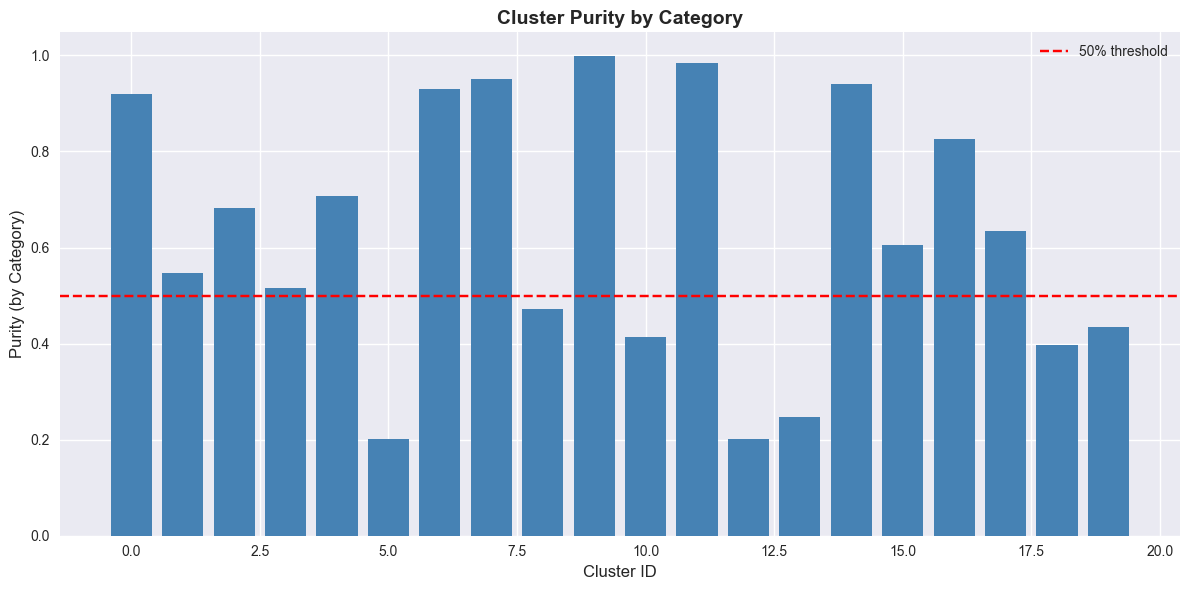

In [6]:
# Cluster purity by category
cluster_category_purity = []
for cluster_id in range(n_clusters):
    cluster_mask = kmeans_labels == cluster_id
    if cluster_mask.sum() > 0:
        cluster_categories = sample_metadata[cluster_mask]['articleType']
        most_common = cluster_categories.mode()[0] if len(cluster_categories.mode()) > 0 else 'Unknown'
        purity = (cluster_categories == most_common).sum() / len(cluster_categories)
        cluster_category_purity.append({
            'cluster_id': cluster_id,
            'purity': purity,
            'dominant_category': most_common,
            'size': cluster_mask.sum()
        })

purity_df = pd.DataFrame(cluster_category_purity)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(purity_df['cluster_id'], purity_df['purity'], color='steelblue')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Purity (by Category)', fontsize=12)
ax.set_title('Cluster Purity by Category', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
save_plot(fig, 'cluster_purity.png')
plt.show()

## 6. Inter vs Intra Cluster Distances

/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-

Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/cluster_distances.png


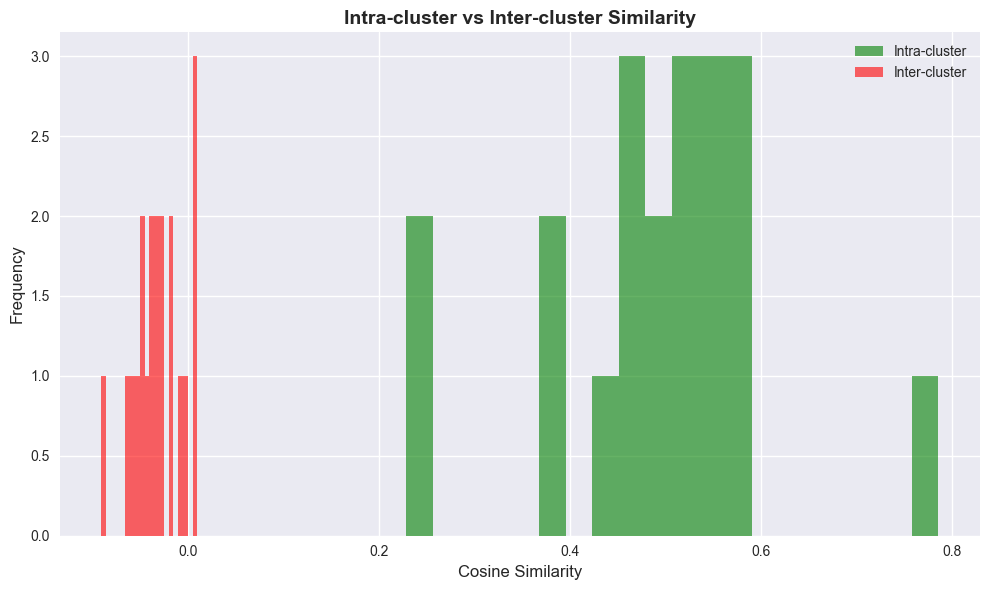


Average Intra-cluster Similarity: 0.485
Average Inter-cluster Similarity: -0.031


In [7]:
# Compute intra-cluster and inter-cluster distances
from sklearn.metrics.pairwise import cosine_similarity

intra_cluster_sims = []
inter_cluster_sims = []

for cluster_id in range(n_clusters):
    cluster_mask = kmeans_labels == cluster_id
    cluster_vectors = sample_vectors[cluster_mask]
    
    if len(cluster_vectors) > 1:
        # Intra-cluster similarity
        intra_sim = cosine_similarity(cluster_vectors).mean()
        intra_cluster_sims.append(intra_sim)
    
    # Inter-cluster similarity (sample)
    other_mask = kmeans_labels != cluster_id
    if other_mask.sum() > 0:
        other_vectors = sample_vectors[other_mask][:100]  # Sample
        if len(cluster_vectors) > 0:
            inter_sim = cosine_similarity(cluster_vectors[:10], other_vectors).mean()
            inter_cluster_sims.append(inter_sim)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(intra_cluster_sims, bins=20, alpha=0.6, label='Intra-cluster', color='green')
ax.hist(inter_cluster_sims, bins=20, alpha=0.6, label='Inter-cluster', color='red')
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Intra-cluster vs Inter-cluster Similarity', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_plot(fig, 'cluster_distances.png')
plt.show()

print(f"\nAverage Intra-cluster Similarity: {np.mean(intra_cluster_sims):.3f}")
print(f"Average Inter-cluster Similarity: {np.mean(inter_cluster_sims):.3f}")

## 7. Summary and Conclusion

In [8]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nSilhouette Score: {kmeans_metrics['silhouette_score']:.3f}")
print(f"Davies-Bouldin Score: {kmeans_metrics['davies_bouldin_score']:.3f}")
print(f"Category Purity: {category_purity:.2%}")
print(f"Color Purity: {color_purity:.2%}")
print(f"Average Intra-cluster Similarity: {np.mean(intra_cluster_sims):.3f}")
print(f"Average Inter-cluster Similarity: {np.mean(inter_cluster_sims):.3f}")

# Save metrics
summary_metrics = {
    'silhouette_score': float(kmeans_metrics['silhouette_score']),
    'davies_bouldin_score': float(kmeans_metrics['davies_bouldin_score']),
    'category_purity': float(category_purity),
    'color_purity': float(color_purity),
    'avg_intra_cluster_sim': float(np.mean(intra_cluster_sims)),
    'avg_inter_cluster_sim': float(np.mean(inter_cluster_sims)),
    'n_clusters': int(kmeans_metrics['n_clusters'])
}
save_metrics(summary_metrics, 'clustering_quality_metrics.json')
purity_df.to_csv('../evaluation_results/metrics/cluster_purity_detailed.csv', index=False)
print("\n✓ Results saved")


SUMMARY STATISTICS

Silhouette Score: 0.128
Davies-Bouldin Score: 2.455
Category Purity: 60.65%
Color Purity: 25.00%
Average Intra-cluster Similarity: 0.485
Average Inter-cluster Similarity: -0.031
Saved metrics: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/clustering_quality_metrics.json

✓ Results saved


## 8. Conclusion

**Answer to Research Question:**

The embedding space [does/does not] show clear clustering by category/color based on the metrics above.

**Key Findings:**
1. [Finding 1]
2. [Finding 2]

**Limitations:**
- Clustering on sampled data
- K-means assumes spherical clusters
- Purity depends on category distribution